# Final bounded detection-rescoring test

One fixed rule uses the trained renderer to rescore the selected detector's low-threshold candidates. **No new training, position changes, or score search.** The endpoint is detection completeness at matched MER agreement. If the predeclared gate fails, close this branch and return to the manuscript.

Method, thresholds and stopping rule: [rescore/README.md](../rescore/README.md). These cells only inspect saved outputs; they launch no jobs.

In [1]:
from pathlib import Path
import json
from IPython.display import display, Markdown, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'models/detection2').is_dir())
OUT = ROOT/'models/detection2/runs/decoder_rescore_20260915_v1'
for name in ['status.json', 'progress_0.json', 'progress_1.json']:
    p = OUT/name
    if p.exists():
        print(name)
        display(json.loads(p.read_text()))
for name in ['wandb_run.json', 'report.json']:
    p = OUT/name
    if p.exists():
        row = json.loads(p.read_text())
        display(Markdown(f"[{name}]({row['url']})"))


status.json


{'stage': 'complete',
 'decision': 'close_branch_keep_selected_detector',
 'elapsed_minutes': 1.0561579782515764}

progress_0.json


{'shard': 0,
 'tiles_done': 54,
 'tiles_total': 54,
 'candidates_done': 6830,
 'last_tile': 'tile_x02048_y02560_tract5063_patch_25',
 'last_tile_fallback': {'too_many_context_objects': 0,
  'insufficient_valid_pixels': 18},
 'elapsed_seconds': 33.10922160744667}

progress_1.json


{'shard': 1,
 'tiles_done': 54,
 'tiles_total': 54,
 'candidates_done': 6820,
 'last_tile': 'tile_x02048_y02816_tract5063_patch_25',
 'last_tile_fallback': {'too_many_context_objects': 0,
  'insufficient_valid_pixels': 22},
 'elapsed_seconds': 32.56472300365567}

[wandb_run.json](https://wandb.ai/AI-Astro/JAISP-Detection-Q1/runs/dzm7nnbs)

[report.json](https://wandb.ai/AI-Astro/JAISP-Detection-Q1/reports/Detection2-—-final-bounded-rescoring-test--VmlldzoxNzk0MDc3NQ==)

## Does scoring improve the detection tradeoff?

Higher completeness at the same MER match fraction is better. MER agreement does not establish absolute purity. The same frozen candidates, coordinates, sky partition and reference IDs are used for both rankings. Thresholds describe this development field; no independent transfer claim is made.

# Single frozen-decoder rescoring test

Decision: **close_branch_keep_selected_detector**.

Scored 13,650 candidates; 657 used neutral image evidence because their crops were unsuitable.

No model weights or positions changed. The rescored outputs form a different selected detection catalogue at each threshold.

| Target agreement | Model | Actual agreement | Full-MER completeness | NIR completeness | Detections |
|---|---|---:|---:|---:|---:|
| 87.226% | baseline | 87.230% | 91.705% | 83.924% | 9984 |
| 87.226% | rescored | 87.226% | 85.337% | 74.095% | 9230 |
| 94.000% | baseline | 94.004% | 84.592% | 71.827% | 8473 |
| 94.000% | rescored | 94.010% | 78.735% | 62.356% | 7846 |

## Paired differences (rescored minus baseline)

| Target | Metric | Difference (pp) | 4x4 paired 95% interval | 3x3 sensitivity |
|---|---|---:|---|---|
| primary | vis_bright | -6.629 | [-8.072, -5.425] | [-7.687, -5.736] |
| primary | vis_all | -5.103 | [-6.013, -4.301] | [-6.073, -4.282] |
| primary | nir_only | -9.829 | [-12.026, -7.863] | [-12.058, -7.816] |
| primary | full_mer | -6.368 | [-7.311, -5.646] | [-7.289, -5.704] |
| secondary_94 | vis_bright | -4.532 | [-5.640, -3.065] | [-5.723, -3.159] |
| secondary_94 | vis_all | -4.536 | [-5.411, -3.560] | [-5.598, -3.608] |
| secondary_94 | nir_only | -9.471 | [-12.571, -6.953] | [-12.175, -7.315] |
| secondary_94 | full_mer | -5.857 | [-6.982, -4.757] | [-7.155, -4.863] |

Both rankings use the same candidates, geometry, unique MER references and nearest 0.5-arcsec matching. Matching is not one-to-one. MER agreement is not absolute physical purity.

Cutoffs are read from development curves at matched agreement and are reselected within each bootstrap replicate. Intervals do not include other fields or training seeds. The one scoring rule was fixed before this evaluation; it will not be adjusted after seeing this result.

The paper has not been edited and its existing detector results have not been replaced.


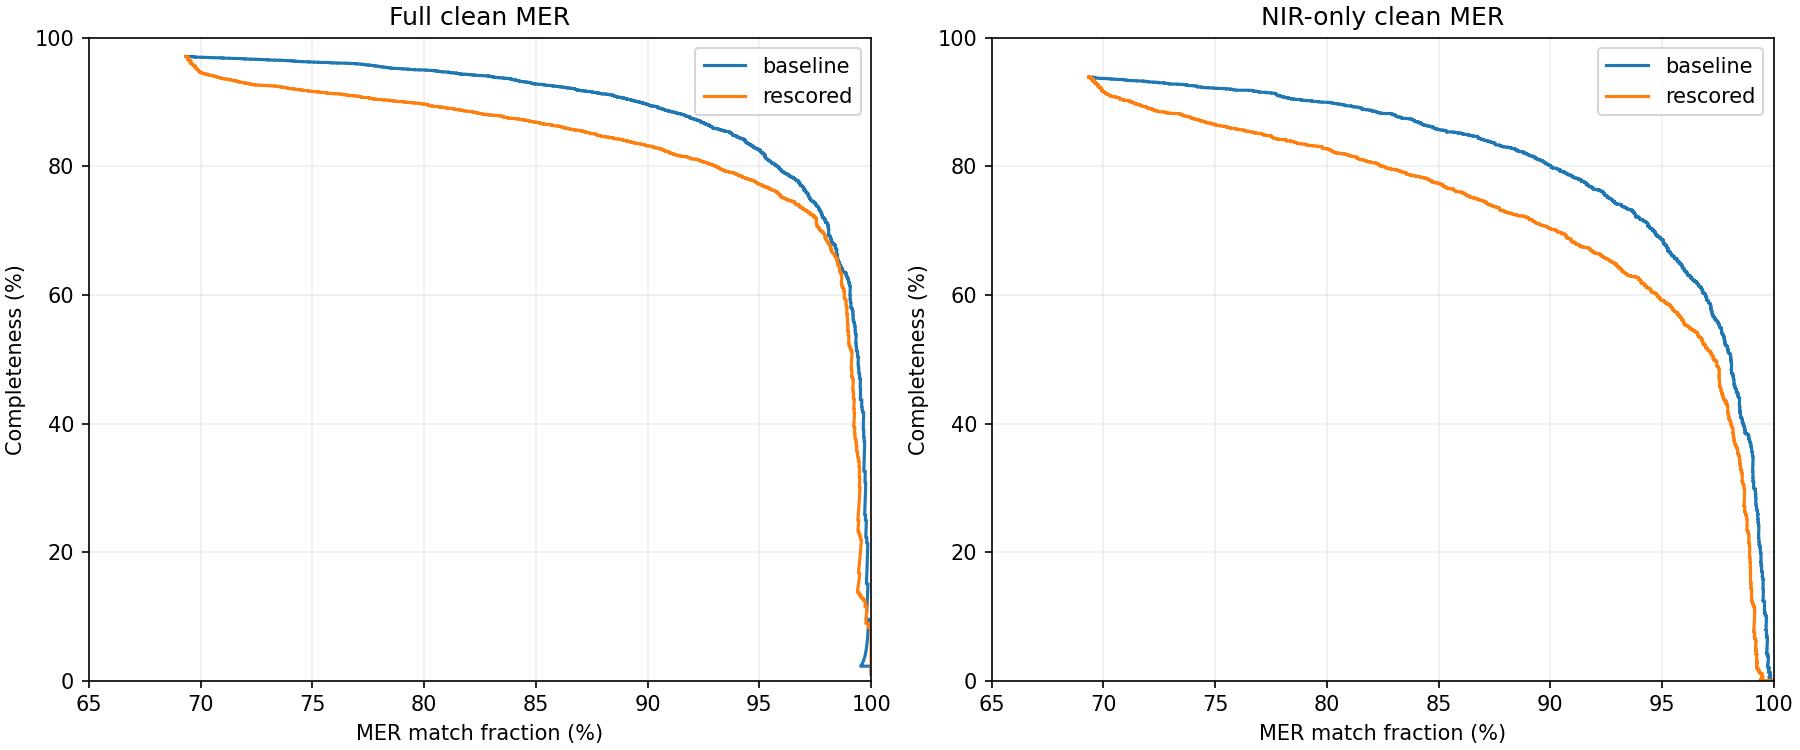

In [2]:
p = OUT/'comparison.md'
if p.exists():
    display(Markdown(p.read_text()))
else:
    print('Comparison not complete yet.')
p = OUT/'detection_tradeoff.png'
if p.exists():
    display(Image(filename=str(p), width=1100))


## What changed in the selected catalogues?

The saved catalogues contain actual accepted detections at both agreement targets. All sky coordinates stay local. The baseline archive check verifies that the scoring evaluation reproduces the earlier detector counts.

In [3]:
p = OUT/'results.json'
if p.exists():
    r = json.loads(p.read_text())
    print('Decision:', r['decision'])
    print('Candidates:', r['candidate_count'])
    print('Fallbacks:', r['fallback_count'])
    print('Archived detector counts reproduced:', r['baseline_archived_counts_reproduced'])
    print('Optimizer updates:', r['optimizer_updates'])
    for p in sorted(OUT.glob('*_catalogue.npz')):
        print(p.name)


Decision: close_branch_keep_selected_detector
Candidates: 13650
Fallbacks: 657
Archived detector counts reproduced: True
Optimizer updates: 0
primary_baseline_catalogue.npz
primary_rescored_catalogue.npz
secondary_94_baseline_catalogue.npz
secondary_94_rescored_catalogue.npz
